In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Classification.xlsx"
)

print("Shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Shape: (3162, 10)


,state,year,residential_billion_btu,commercial_billion_btu,industrial_billion_btu,transportation_billion_btu,co2_lag_1,co2_lag_2,energy_growth_rate,co2_growth_rate
0,AK,1962,10472,7129,24859,34182,4.846,4.040,9.457298,9.925712
1,AK,1963,11256,9246,25598,32387,5.327,4.846,2.408601,0.732119
2,AK,1964,13004,12021,25522,32246,5.366,5.327,5.484915,4.733507
3,AK,1965,13857,14210,22874,34379,5.620,5.366,3.050983,1.779359
4,AK,1966,15563,15066,33619,36233,5.720,5.620,17.770954,19.090909


['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate']


In [2]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

state                             str
year                            int64
residential_billion_btu         int64
commercial_billion_btu          int64
industrial_billion_btu          int64
transportation_billion_btu      int64
co2_lag_1                     float64
co2_lag_2                     float64
energy_growth_rate            float64
co2_growth_rate               float64
dtype: object

Missing values:
state                         0
year                          0
residential_billion_btu       0
commercial_billion_btu        0
industrial_billion_btu        0
transportation_billion_btu    0
co2_lag_1                     0
co2_lag_2                     0
energy_growth_rate            0
co2_growth_rate               0
dtype: int64


In [3]:
print(df.columns.tolist())
for col in df.columns:
    print("\n", col)
    print(df[col].value_counts().head(10))

['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate']

 state
state
AK    62
AL    62
AR    62
AZ    62
CA    62
CO    62
CT    62
DC    62
DE    62
FL    62
Name: count, dtype: int64

 year
year
1962    51
1963    51
1964    51
1965    51
1966    51
1967    51
1968    51
1969    51
1970    51
1971    51
Name: count, dtype: int64

 residential_billion_btu
residential_billion_btu
46335     2
205432    2
334446    2
74215     2
341958    2
140674    2
33036     2
76843     2
10472     1
11256     1
Name: count, dtype: int64

 commercial_billion_btu
commercial_billion_btu
66173     2
42222     2
493149    2
9204      2
37868     2
28780     2
348591    2
44565     2
160679    2
7129      1
Name: count, dtype: int64

 industrial_billion_btu
industrial_billion_btu
24859     2
406022    2
137933    2
281360    2
158640    2
155020    2
251290    2
212845

In [4]:
target_column = "risk_level"

In [6]:
print(df.columns.tolist())
print(df.shape)
print(df.head())
print(df.dtypes)

['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate']
(3162, 10)
  state  year  residential_billion_btu  commercial_billion_btu  \
0    AK  1962                    10472                    7129   
1    AK  1963                    11256                    9246   
2    AK  1964                    13004                   12021   
3    AK  1965                    13857                   14210   
4    AK  1966                    15563                   15066   

   industrial_billion_btu  transportation_billion_btu  co2_lag_1  co2_lag_2  \
0                   24859                       34182      4.846      4.040   
1                   25598                       32387      5.327      4.846   
2                   25522                       32246      5.366      5.327   
3                   22874                       34379      5.620      5.366   
4  

In [7]:
reg_df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)

print(reg_df.columns.tolist())
print(reg_df[["state", "year", "co2_next_year"]].head(10))
print(reg_df.shape)

['state', 'year', 'residential_billion_btu', 'commercial_billion_btu', 'industrial_billion_btu', 'transportation_billion_btu', 'co2_lag_1', 'co2_lag_2', 'energy_growth_rate', 'co2_growth_rate', 'co2_next_year']
  state  year  co2_next_year
0    AK  1962          5.366
1    AK  1963          5.620
2    AK  1964          5.720
3    AK  1965          6.812
4    AK  1966          7.801
5    AK  1967          8.170
6    AK  1968         10.014
7    AK  1969         11.356
8    AK  1970         12.643
9    AK  1971         13.432
(3162, 11)


In [8]:
import pandas as pd

# Load both datasets
classification_df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Classification.xlsx"
)

regression_df = pd.read_excel(
    "../data/processed/CarbonOpt_XGBoost_Regression.xlsx"
)

# Add future CO2 to classification data
classification_df["co2_next_year"] = regression_df["co2_next_year"]

print(classification_df.head())
print(classification_df.shape)

  state  year  residential_billion_btu  commercial_billion_btu  \
0    AK  1962                    10472                    7129   
1    AK  1963                    11256                    9246   
2    AK  1964                    13004                   12021   
3    AK  1965                    13857                   14210   
4    AK  1966                    15563                   15066   

   industrial_billion_btu  transportation_billion_btu  co2_lag_1  co2_lag_2  \
0                   24859                       34182      4.846      4.040   
1                   25598                       32387      5.327      4.846   
2                   25522                       32246      5.366      5.327   
3                   22874                       34379      5.620      5.366   
4                   33619                       36233      5.720      5.620   

   energy_growth_rate  co2_growth_rate  co2_next_year  
0            9.457298         9.925712          5.366  
1            2.4

In [9]:
low_threshold = classification_df["co2_next_year"].quantile(0.33)
high_threshold = classification_df["co2_next_year"].quantile(0.67)

print("Low threshold :", low_threshold)
print("High threshold:", high_threshold)

Low threshold : 43.19413
High threshold: 99.86848


In [10]:
def classify_risk(co2):
    if co2 <= low_threshold:
        return "Low"
    elif co2 <= high_threshold:
        return "Medium"
    else:
        return "High"

classification_df["risk_class"] = (
    classification_df["co2_next_year"]
    .apply(classify_risk)
)

In [11]:
print(
    classification_df[
        ["state", "year", "co2_next_year", "risk_class"]
    ].head(20)
)

   state  year  co2_next_year risk_class
0     AK  1962          5.366        Low
1     AK  1963          5.620        Low
2     AK  1964          5.720        Low
3     AK  1965          6.812        Low
4     AK  1966          7.801        Low
5     AK  1967          8.170        Low
6     AK  1968         10.014        Low
7     AK  1969         11.356        Low
8     AK  1970         12.643        Low
9     AK  1971         13.432        Low
10    AK  1972         12.505        Low
11    AK  1973         12.791        Low
12    AK  1974         14.540        Low
13    AK  1975         15.978        Low
14    AK  1976         17.966        Low
15    AK  1977         19.512        Low
16    AK  1978         17.534        Low
17    AK  1979         17.438        Low
18    AK  1980         17.081        Low
19    AK  1981         24.016        Low


In [12]:
print(classification_df["risk_class"].value_counts())
print(
    classification_df["risk_class"]
    .value_counts(normalize=True)
    .mul(100)
)

risk_class
Medium    1074
Low       1044
High      1044
Name: count, dtype: int64
risk_class
Medium    33.965844
Low       33.017078
High      33.017078
Name: proportion, dtype: float64


In [13]:
years = sorted(classification_df["year"].unique())

n_test_years = max(1, int(len(years) * 0.20))

train_years = years[:-n_test_years]
test_years = years[-n_test_years:]

train_df = classification_df[
    classification_df["year"].isin(train_years)
].copy()

test_df = classification_df[
    classification_df["year"].isin(test_years)
].copy()

print("Training years:", train_years[0], "to", train_years[-1])
print("Testing years :", test_years[0], "to", test_years[-1])

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

Training years: 1962 to 2011
Testing years : 2012 to 2023
Training shape: (2550, 12)
Testing shape : (612, 12)


In [14]:
low_threshold = train_df["co2_next_year"].quantile(0.33)
high_threshold = train_df["co2_next_year"].quantile(0.67)

print("Training Low threshold :", low_threshold)
print("Training High threshold:", high_threshold)

Training Low threshold : 41.83780000000001
Training High threshold: 100.11748000000003


In [15]:
def classify_risk(co2):
    if co2 <= low_threshold:
        return "Low"
    elif co2 <= high_threshold:
        return "Medium"
    else:
        return "High"

In [16]:
train_df["risk_class"] = train_df["co2_next_year"].apply(classify_risk)

test_df["risk_class"] = test_df["co2_next_year"].apply(classify_risk)

In [17]:
print("Training class distribution:")
print(train_df["risk_class"].value_counts())

print("\nTesting class distribution:")
print(test_df["risk_class"].value_counts())

Training class distribution:
risk_class
Medium    866
Low       842
High      842
Name: count, dtype: int64

Testing class distribution:
risk_class
Medium    248
High      198
Low       166
Name: count, dtype: int64


In [18]:
features = [
    "state",
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

X_train = train_df[features]
y_train = train_df["risk_class"]

X_test = test_df[features]
y_test = test_df["risk_class"]

In [19]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (2550, 10)
y_train: (2550,)
X_test : (612, 10)
y_test : (612,)


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['High' 'Low' 'Medium']


In [21]:
from xgboost import XGBClassifier

classifier = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["state"]

numerical_features = [
    "year",
    "residential_billion_btu",
    "commercial_billion_btu",
    "industrial_billion_btu",
    "transportation_billion_btu",
    "co2_lag_1",
    "co2_lag_2",
    "energy_growth_rate",
    "co2_growth_rate"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "state",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [23]:
from sklearn.pipeline import Pipeline

classification_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ]
)

In [24]:
classification_model.fit(
    X_train,
    y_train_encoded
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['state','year','residential_billion_btu',...,'co2_lag_2', 'energy_growth_rate','co2_growth_rate']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [25]:
y_pred_encoded = classification_model.predict(X_test)

print(y_pred_encoded[:20])

[1 1 1 1 1 1 1 1 1 1 1 2 0 0 0 0 0 0 0 0]


In [26]:
y_pred = label_encoder.inverse_transform(y_pred_encoded)

print(y_pred[:20])

['Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Low' 'Low'
 'Medium' 'High' 'High' 'High' 'High' 'High' 'High' 'High' 'High']


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test_encoded, y_pred_encoded)

precision = precision_score(
    y_test_encoded,
    y_pred_encoded,
    average="weighted"
)

recall = recall_score(
    y_test_encoded,
    y_pred_encoded,
    average="weighted"
)

f1 = f1_score(
    y_test_encoded,
    y_pred_encoded,
    average="weighted"
)

print("XGBoost Classification Performance")
print("-----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

XGBoost Classification Performance
-----------------------------------
Accuracy : 0.9608
Precision: 0.9621
Recall   : 0.9608
F1 Score : 0.9607


In [28]:
print(
    classification_report(
        y_test_encoded,
        y_pred_encoded,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.98      0.91      0.94       198
         Low       0.99      0.99      0.99       166
      Medium       0.93      0.98      0.95       248

    accuracy                           0.96       612
   macro avg       0.97      0.96      0.96       612
weighted avg       0.96      0.96      0.96       612



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_encoded
)

print(cm)

[[180   0  18]
 [  0 165   1]
 [  3   2 243]]


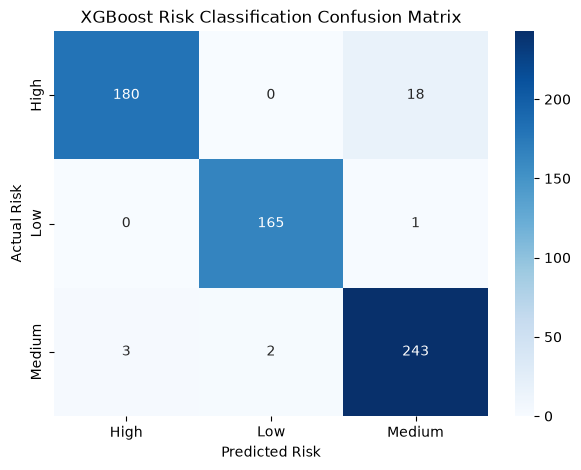

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("XGBoost Risk Classification Confusion Matrix")

plt.show()

In [31]:
results = test_df[
    ["state", "year", "co2_next_year", "risk_class"]
].copy()

results["predicted_risk"] = y_pred

results["correct"] = (
    results["risk_class"] ==
    results["predicted_risk"]
)

print(results.head(20))


    state  year  co2_next_year risk_class predicted_risk  correct
50     AK  2012         34.298        Low            Low     True
51     AK  2013         34.163        Low            Low     True
52     AK  2014         35.073        Low            Low     True
53     AK  2015         33.449        Low            Low     True
54     AK  2016         33.778        Low            Low     True
55     AK  2017         34.573        Low            Low     True
56     AK  2018         34.459        Low            Low     True
57     AK  2019         36.236        Low            Low     True
58     AK  2020         39.969        Low            Low     True
59     AK  2021         42.327     Medium            Low    False
60     AK  2022         43.365     Medium            Low    False
61     AK  2023         44.008     Medium         Medium     True
112    AL  2012        120.330       High           High     True
113    AL  2013        122.536       High           High     True
114    AL 

In [32]:
from pathlib import Path

MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs/classification")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [33]:
import joblib

joblib.dump(
    classification_model,
    MODEL_DIR / "xgb_classification.pkl"
)

joblib.dump(
    label_encoder,
    MODEL_DIR / "risk_label_encoder.pkl"
)
results.to_csv(
    OUTPUT_DIR / "classification_predictions.csv",
    index=False
)

In [1]:
with open(OUTPUT_DIR / "metrics.txt", "w") as f:
    f.write("XGBoost Classification Performance\n")
    f.write("----------------------------------\n")
    f.write(f"Accuracy : {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall   : {recall:.4f}\n")
    f.write(f"F1 Score : {f1:.4f}\n")

NameError: name 'OUTPUT_DIR' is not defined